# ChromaDB와 Text2SQL
* Day 16 핵심 개념을 **짧은 코드로 한 번씩** 확인합니다.
* 데이터: `rag_data/` 의 **학부 학칙**·**일반대학원 학칙** PDF, `table_data.csv`


---
* `day15` Conda 환경을 사용합니다.
* Chroma·PDF·웹검색·SQLite 관련 패키지를 설치합니다.

In [2]:
!pip install langchain langchain-openai langchain-community langchain-chroma langchain-text-splitters langgraph pypdf chromadb ddgs pandas

  Using cached pypdf-6.14.2-py3-none-any.whl.metadata (7.2 kB)
  Using cached chromadb-1.5.9-cp39-abi3-win_amd64.whl.metadata (5.1 kB)
  Using cached httpx_sse-0.4.3-py3-none-any.whl.metadata (9.7 kB)
  Using cached aiosignal-1.4.0-py3-none-any.whl.metadata (3.7 kB)
  Using cached attrs-26.1.0-py3-none-any.whl.metadata (8.8 kB)
  Using cached uvicorn-0.51.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached pypika-0.51.1-py2.py3-none-any.whl.metadata (51 kB)
  Using cached overrides-7.7.0-py3-none-any.whl.metadata (5.8 kB)
  Using cached bcrypt-5.0.0-cp39-abi3-win_amd64.whl.metadata (10 kB)
  Using cached rich-15.0.0-py3-none-any.whl.metadata (18 kB)
  Using cached click-8.4.2-py3-none-any.whl.metadata (2.6 kB)
  Using cached tzdata-2026.3-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached pyproject_hooks-1.2.0-py3-none-any.whl.metadata (1.3 kB)
  Using cached jsonschema_specifications-2025.9.1-py3-none-any.whl.metadata (2.9 kB)
  Using cached websocket_client-1.9.0-py3-none-any.whl.

In [3]:
from pathlib import Path
from dotenv import load_dotenv

load_dotenv()
OPENAI_API_KEY = __import__('os').getenv('OPENAI_API_KEY')

WORKDIR = Path.cwd()
RAG_DIR = WORKDIR / 'rag_data'
PDF_PATHS = sorted(RAG_DIR.glob('*.pdf'))  # 학부 + 일반대학원
CSV_PATH = RAG_DIR / 'table_data.csv'
CHROMA_DIR = WORKDIR / 'chroma_regulations'  # 학부·대학원 함께 인덱싱

print('WORKDIR :', WORKDIR)
print('PDFs    :', [p.name for p in PDF_PATHS])
print('CSV     :', CSV_PATH.name)


WORKDIR : c:\Users\Admin\OneDrive\바탕 화면\실습\16일차_실습
PDFs    : ['연세대학교 일반대학원 학칙.pdf', '연세대학교 학부 학칙.pdf']
CSV     : table_data.csv


In [4]:
PDF_PATHS

[WindowsPath('c:/Users/Admin/OneDrive/바탕 화면/실습/16일차_실습/rag_data/연세대학교 일반대학원 학칙.pdf'),
 WindowsPath('c:/Users/Admin/OneDrive/바탕 화면/실습/16일차_실습/rag_data/연세대학교 학부 학칙.pdf')]

In [5]:
PDF_PATHS[0].name

'연세대학교 일반대학원 학칙.pdf'

---
## 1. ChromaDB 구축

| 선택지 | 특징 |
|--------|------|
| FAISS | 가볍고 빠르지만, 운영·영구저장 기능이 약함 |
| ChromaDB | 로컬 persist 가능, LangChain 연동이 편함 |
| Milvus / Pinecone | 대규모·클라우드 |

### PDF 로드
* 학부 / 일반대학원 PDF를 각각 읽고, 파일명 기준으로 `level` 메타데이터를 붙입니다.


In [8]:
loaded[0] #배열

Document(metadata={'producer': 'Skia/PDF m150', 'creator': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/150.0.0.0 Safari/537.36', 'creationdate': '2026-07-11T13:36:30+00:00', 'title': '연세대학교 학칙 ::연세대학교 규정집', 'moddate': '2026-07-11T13:36:30+00:00', 'source': 'c:\\Users\\Admin\\OneDrive\\바탕 화면\\실습\\16일차_실습\\rag_data\\연세대학교 학부 학칙.pdf', 'total_pages': 41, 'page': 0, 'page_label': '1', 'level': '학부', 'doc_type': '학칙', 'source_file': '연세대학교 학부 학칙.pdf'}, page_content='제정일: 1956.04.03\n개정일: 2026.02.12\n담당부서: 교무처 - 교무팀(02-2123-2082)\n제1조 (목적)\n본 대학교는 기독교 정신에 기하여 학술의 심오한 이론과 광범 정치한 응용 방법을 교수 연\n구하며, 국가와 인류 사회 발전에 공헌할 지도적 인격을 도야함을 목적으로 한다.\n제2조 (교육조직)\n본 대학교에 대학으로서 문과대학, 상경대학, 경영대학, 이과대학, 공과대학, 생명시스템대학,\n인공지능융합대학, 신과대학, 사회과학대학, 음악대학, 생활과학대학, 교육과학대학, 학부대\n학, 언더우드국제대학, 글로벌인재대학, 의과대학, 치과대학, 간호대학, 약학대학, 글로벌창의\n융합대학, 과학기술대학, 보건과학대학, 원주의과대학, 원주간호대학, RC융합대학, 일반대학\n원으로서 대학원, 전문대학원으로서 연합신학대학원, 경영전문대학원, 국제학대학원, 정보대\n학원, 커뮤니케이션대학원, 사회복지대학원, 법학전문대학원, 융합보건의료대학원, 간호전

In [9]:
from langchain_community.document_loaders import PyPDFLoader


def infer_level(filename: str) -> str:
    """파일명으로 학부 / 대학원을 구분합니다. (학부를 먼저 검사)"""
    if '학부' in filename:
        return '학부'
    if '대학원' in filename:
        return '대학원'
    return '기타'

#infer_level로 문서의 level 구분(학부, 대학원)
pages = []
for pdf_path in PDF_PATHS:
    loaded = PyPDFLoader(str(pdf_path)).load()
    level = infer_level(pdf_path.name)
    for doc in loaded:
        doc.metadata['level'] = level
        doc.metadata['doc_type'] = '학칙'
        doc.metadata['source_file'] = pdf_path.name
    print(f'{pdf_path.name} → level={level}, pages={len(loaded)}')
    pages.extend(loaded)

print('총 페이지:', len(pages))
print(pages[0].metadata)
print(pages[0].page_content[:200])
print(pages[1].metadata)
print(pages[1].page_content[:200])


연세대학교 일반대학원 학칙.pdf → level=대학원, pages=35
연세대학교 학부 학칙.pdf → level=학부, pages=41
총 페이지: 76
{'producer': 'Hancom PDF 1.3.0.550', 'creator': 'Hwp 2024 13.0.0.3457', 'creationdate': '2026-06-17T16:37:51+09:00', 'author': 'DR', 'moddate': '2026-06-17T16:37:51+09:00', 'pdfversion': '1.4', 'source': 'c:\\Users\\Admin\\OneDrive\\바탕 화면\\실습\\16일차_실습\\rag_data\\연세대학교 일반대학원 학칙.pdf', 'total_pages': 35, 'page': 0, 'page_label': '1', 'level': '대학원', 'doc_type': '학칙', 'source_file': '연세대학교 일반대학원 학칙.pdf'}
Ⅰ. 대학원 학칙  /  7
Ⅰ. 대학원 학칙제정: 1974. 05. 18.개정(제122차): 2026. 06. 06.제1장 총칙제1조(목적) 대학원은 기독교 정신을 바탕으로 하여 창의적 이론과 과학적 방법을 탐구하고, 지도적 인격을 도야하여 인류 문화 향상에 기여함을 목적으로 한다.제2장 과정 및 정원제2조(과정) 대학원에는 석사학위를 취득하기 위한 석사
{'producer': 'Hancom PDF 1.3.0.550', 'creator': 'Hwp 2024 13.0.0.3457', 'creationdate': '2026-06-17T16:37:51+09:00', 'author': 'DR', 'moddate': '2026-06-17T16:37:51+09:00', 'pdfversion': '1.4', 'source': 'c:\\Users\\Admin\\OneDrive\\바탕 화면\\실습\\16일차_실습\\rag_data\\연세대학교 일반대학원 학칙.pdf', 'total_pages': 35, 'pag

### Chunk + overlap
* chunk가 너무 작으면 문맥이 끊기고, 너무 크면 주제가 섞입니다.
* `chunk_overlap`으로 경계에서 문맥이 끊기는 것을 줄입니다.

In [10]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

splitter = RecursiveCharacterTextSplitter(chunk_size=800, chunk_overlap=120)
chunks = splitter.split_documents(pages)
print('chunk 수:', len(chunks))

chunk 수: 195


In [11]:
print(chunks[0].page_content[:400])
print('--- metadata ---')
print(chunks[0].metadata)

Ⅰ. 대학원 학칙  /  7
--- metadata ---
{'producer': 'Hancom PDF 1.3.0.550', 'creator': 'Hwp 2024 13.0.0.3457', 'creationdate': '2026-06-17T16:37:51+09:00', 'author': 'DR', 'moddate': '2026-06-17T16:37:51+09:00', 'pdfversion': '1.4', 'source': 'c:\\Users\\Admin\\OneDrive\\바탕 화면\\실습\\16일차_실습\\rag_data\\연세대학교 일반대학원 학칙.pdf', 'total_pages': 35, 'page': 0, 'page_label': '1', 'level': '대학원', 'doc_type': '학칙', 'source_file': '연세대학교 일반대학원 학칙.pdf'}


### Metadata 태깅
* 벡터 유사도만 쓰면 학부·대학원 조항이 섞여 나올 수 있습니다.
* 로드 단계에서 붙인 `level`(`학부` / `대학원`)을 chunk에도 유지하고, 검색 시 필터에 사용합니다.


In [12]:
# chunk로 나눈 뒤에도 level이 유지되는지 확인
from collections import Counter

level_counts = Counter(c.metadata.get('level') for c in chunks)
print('level별 chunk 수:', dict(level_counts))

for level in ['학부', '대학원']:
    sample = next(c for c in chunks if c.metadata.get('level') == level)
    print(f'[{level}]', sample.metadata)


level별 chunk 수: {'대학원': 102, '학부': 93}
[학부] {'producer': 'Skia/PDF m150', 'creator': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/150.0.0.0 Safari/537.36', 'creationdate': '2026-07-11T13:36:30+00:00', 'title': '연세대학교 학칙 ::연세대학교 규정집', 'moddate': '2026-07-11T13:36:30+00:00', 'source': 'c:\\Users\\Admin\\OneDrive\\바탕 화면\\실습\\16일차_실습\\rag_data\\연세대학교 학부 학칙.pdf', 'total_pages': 41, 'page': 0, 'page_label': '1', 'level': '학부', 'doc_type': '학칙', 'source_file': '연세대학교 학부 학칙.pdf'}
[대학원] {'producer': 'Hancom PDF 1.3.0.550', 'creator': 'Hwp 2024 13.0.0.3457', 'creationdate': '2026-06-17T16:37:51+09:00', 'author': 'DR', 'moddate': '2026-06-17T16:37:51+09:00', 'pdfversion': '1.4', 'source': 'c:\\Users\\Admin\\OneDrive\\바탕 화면\\실습\\16일차_실습\\rag_data\\연세대학교 일반대학원 학칙.pdf', 'total_pages': 35, 'page': 0, 'page_label': '1', 'level': '대학원', 'doc_type': '학칙', 'source_file': '연세대학교 일반대학원 학칙.pdf'}


### Embedding 모델
* 모델마다 벡터 공간이 달라, 나중에 바꾸면 **전체 재인덱싱**이 필요합니다.
* 오늘은 실습 편의를 위해 OpenAI `text-embedding-3-small` 을 사용합니다.
* 거리 함수는 텍스트 검색에서 흔한 **cosine** 으로 맞춥니다.

In [13]:
from langchain_openai import OpenAIEmbeddings

embedding = OpenAIEmbeddings(
    model='text-embedding-3-small',
    api_key=OPENAI_API_KEY,
)

v = embedding.embed_query('석사 수업연한은 몇 년인가?')
print('차원 수:', len(v))

차원 수: 1536


### Collection 저장 (persist)
* 한 번 인덱싱하면 프로그램을 껐다 켜도 불러와 씁니다.
* 학부·대학원 PDF를 함께 넣었으므로, 예전에 만든 `chroma_hakchik` 폴더가 있어도 **이 셀의 `chroma_regulations`** 를 사용합니다.
* 폴더가 이미 있으면 재임베딩하지 않고 로드합니다. (다시 짓고 싶으면 해당 폴더를 삭제)


In [14]:
from langchain_chroma import Chroma

if not CHROMA_DIR.exists():
    print('Creating new Chroma store')
    vectorstore = Chroma.from_documents(
        documents=chunks,
        embedding=embedding,
        persist_directory=str(CHROMA_DIR),
        collection_metadata={'hnsw:space': 'cosine'},
    )
else:
    print('Loading existing Chroma store')
    vectorstore = Chroma(
        persist_directory=str(CHROMA_DIR),
        embedding_function=embedding,
    )

Creating new Chroma store


### 유사도 검색 (top-k)
* top-k가 너무 작으면 근거가 빠지고, 너무 크면 노이즈가 늘어납니다.
* 처음엔 넉넉히 가져온 뒤 Relevance Checker로 걸러내는 구성이 무난합니다.

In [15]:
QUERY = '석사학위과정의 수업연한은 얼마인가?'
docs = vectorstore.similarity_search(QUERY, k=3)

for i, d in enumerate(docs, 1):
    print(f'[{i}] page={d.metadata.get("page")} | {d.page_content[:180]}')
    print('---')

[1] page=3 | 제4조 (수업연한) ① 학사학위과정의 수업연한은 4년(8학기)으로 한다. 다만 다음 각 호는 예
외로 한다.
1. 의예과, 치의예과: 2년(4학기)
2. 약학과: 6년(12학기)
3. 야간간호학과(RN-BSN), 보건과학부(특별학사학위과정) 3학년 편입생: 2년(4학기)
4. 건축학(5년제): 5년(10학기)
5. 편입학
---
[2] page=1 | ③ <삭제> 제2조의7(수업연한) ① 대학원 각 학위과정의 수업연한은 다음 각호와 같다.1. 석사학위과정: 2년(4학기)2. 박사학위과정: 2년(4학기)3. 통합과정: 3년(6학기)② 제1항의 규정에도 불구하고 학위수여 자격 요건을 충족한 학생은 수업연한을 1학기 단축할 수 있다. 단, 통합과정 및 석사학위논문 대체실적을
---
[3] page=12 | ① 재학생은 소정 기간 내에 당해 학기에 이수할 과목을 학부(과)장, 해당전공 책임교수 또는
담당 학사지도사(Academic Advisor)의 지도를 받아 수강신청을 해야한다. <개정
2020.11.06>
② 이수 결과 과락된 과목이 필수과목일 때에는 이를 재수강하여야 한다. 그러나 선택 과목일
때에는 다른 과목을 선택하
---


### Metadata 필터
* `level`로 후보를 먼저 좁힌 뒤, 그 안에서 유사도 순위를 매깁니다.
* 같은 질문이라도 학부 / 대학원 필터 결과가 달라지는지 비교합니다.


In [16]:
QUERY = '수업연한은 얼마인가?'

print('=== 필터 없음 (학부·대학원 섞일 수 있음) ===')
mixed = vectorstore.similarity_search(QUERY, k=3)
for d in mixed:
    print(d.metadata.get('level'), '|', d.metadata.get('source_file'), '|', d.page_content[:100].replace('\n', ' '))
    print('---')

for level in ['학부', '대학원']:
    print(f'=== filter level={level} ===')
    filtered = vectorstore.similarity_search(QUERY, k=2, filter={'level': level})
    print('건수:', len(filtered))
    for d in filtered:
        print(d.metadata.get('level'), '|', d.page_content[:120].replace('\n', ' '))
        print('---')


=== 필터 없음 (학부·대학원 섞일 수 있음) ===
학부 | 연세대학교 학부 학칙.pdf | 제4조 (수업연한) ① 학사학위과정의 수업연한은 4년(8학기)으로 한다. 다만 다음 각 호는 예 외로 한다. 1. 의예과, 치의예과: 2년(4학기) 2. 약학과: 6년(12학기) 
---
학부 | 연세대학교 학부 학칙.pdf | 2017.05.23., 2016.11.11., 별표개정 2016.05.04., 2016.03.04., 2015.11.3., 2015.5.7., 2014.7.22, 2013.12.2
---
학부 | 연세대학교 학부 학칙.pdf | ① 건전한 학풍을 조성하고 학생 자치활동을 신장시키기 위하여 연세대학교 총학생회를 둔 다. 제10장 특별학생 등 제11장 학생활동 26. 7. 11. 오후  10:36 연세대학교 
---
=== filter level=학부 ===
건수: 2
학부 | 제4조 (수업연한) ① 학사학위과정의 수업연한은 4년(8학기)으로 한다. 다만 다음 각 호는 예 외로 한다. 1. 의예과, 치의예과: 2년(4학기) 2. 약학과: 6년(12학기) 3. 야간간호학과(RN-BSN), 보
---
학부 | 2017.05.23., 2016.11.11., 별표개정 2016.05.04., 2016.03.04., 2015.11.3., 2015.5.7., 2014.7.22, 2013.12.23, 2013.11.12, 2013.
---
=== filter level=대학원 ===
건수: 2
대학원 | ③ <삭제> 제2조의7(수업연한) ① 대학원 각 학위과정의 수업연한은 다음 각호와 같다.1. 석사학위과정: 2년(4학기)2. 박사학위과정: 2년(4학기)3. 통합과정: 3년(6학기)② 제1항의 규정에도 불구하고 학위
---
대학원 | ② <삭제>③ 학위과정별, 대상자별 수료학점 인정에 대한 세부 사항은 따로 정한다.제18조 <삭제>제19조(수강과목) ① 학생은 소정의 교과과정에 의하여 개설된 수강과목을 선택할 수 있다.② 학생은 대면과목 이외에도
---


---
## 2. Relevance Checker + 웹 검색 보강

벡터 유사도가 높다고 해서 질문에 답이 되는 문서는 아닙니다.

```
Retrieve → Relevance Check → (통과) Generate
                           → (실패) Web Search → Generate
```

### State 정의

In [17]:
from typing import Literal

from langchain_openai import ChatOpenAI
from pydantic import BaseModel, Field


class RagState(BaseModel):
    question: str
    level: Literal['학부', '대학원', ''] = ''  # 비우면 필터 없음
    docs: list[str] = Field(default_factory=list)
    relevant: bool = False
    answer: str = ''
    source: Literal['rag', 'web', ''] = ''


llm = ChatOpenAI(model='gpt-4o-mini', temperature=0, api_key=OPENAI_API_KEY)


### Retrieve Node

In [18]:
def retrieve_node(state: RagState) -> dict:
    kwargs = {'k': 4}
    if state.level:
        kwargs['filter'] = {'level': state.level}
    hits = vectorstore.similarity_search(state.question, **kwargs)
    docs = [
        f"[level={d.metadata.get('level')}] {d.page_content}"
        for d in hits
    ]
    print('retrieve filter:', state.level or '(없음)', '| hits:', len(docs))
    return {'docs': docs}


### Relevance Check Node
* LLM에게 "이 문서가 질문에 답이 되는가"를 물어 통과/탈락을 가릅니다. (정성적 방식)

In [19]:
def relevance_node(state: RagState) -> dict:
    context = '\n\n'.join(state.docs)
    prompt = (
        f'질문: {state.question}\n\n'
        f'문서:\n{context}\n\n'
        '문서만으로 질문에 답할 수 있으면 YES, 아니면 NO만 출력하세요.'
    )
    verdict = llm.invoke(prompt).content.strip().upper()
    ok = verdict.startswith('YES')
    print('Relevance:', verdict, '→', ok)
    return {'relevant': ok}

### Generate / Web Search Node

In [20]:
import json

from ddgs import DDGS
from ddgs.exceptions import DDGSException


def generate_node(state: RagState) -> dict:
    context = '\n\n'.join(state.docs)
    prompt = (
        '아래 문서를 근거로 질문에 두세 문장으로 답하세요.\n\n'
        f'문서:\n{context}\n\n질문: {state.question}'
    )
    return {'answer': llm.invoke(prompt).content, 'source': 'rag'}


def web_search_node(state: RagState) -> dict:
    try:
        with DDGS() as ddgs:
            results = list(ddgs.text(state.question, max_results=3))
    except DDGSException:
        results = []
    context = json.dumps(results, ensure_ascii=False) if results else '검색 결과 없음'
    prompt = (
        '내부 학칙에서 답을 찾지 못했습니다. 웹 검색 결과를 참고해 답하세요.\n'
        '확실하지 않으면 그 사실을 명시하세요.\n\n'
        f'검색결과:\n{context}\n\n질문: {state.question}'
    )
    return {'answer': llm.invoke(prompt).content, 'source': 'web'}

### 그래프 연결

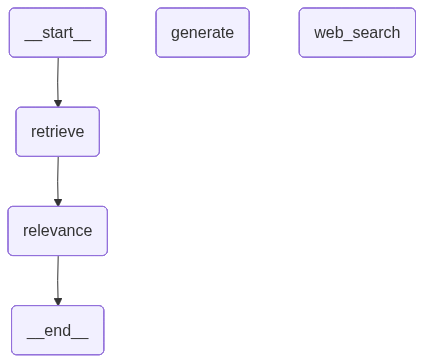

In [21]:
from langgraph.graph import END, START, StateGraph


def route_after_relevance(state: RagState):
    return 'generate' if state.relevant else 'web_search'


rag_wf = StateGraph(RagState)
rag_wf.add_node('retrieve', retrieve_node)
rag_wf.add_node('relevance', relevance_node)
rag_wf.add_node('generate', generate_node)
rag_wf.add_node('web_search', web_search_node)

rag_wf.add_edge(START, 'retrieve')
rag_wf.add_edge('retrieve', 'relevance')
rag_wf.add_conditional_edges('relevance', route_after_relevance)
rag_wf.add_edge('generate', END)
rag_wf.add_edge('web_search', END)

rag_app = rag_wf.compile()
rag_app

### 실행 — 학칙에 있을 법한 질문

In [22]:
# 대학원 학칙만 보고 싶을 때 level='대학원'
out = rag_app.invoke(RagState(question='석사학위과정의 수업연한은 얼마인가요?', level='대학원'))
print('source:', out['source'])
print(out['answer'])


retrieve filter: 대학원 | hits: 4
Relevance: YES → True
source: rag
석사학위과정의 수업연한은 2년(4학기)입니다.


### 실행 — 학칙에 없을 법한 질문 (웹 검색으로 넘어가는지 확인)

In [23]:
out = rag_app.invoke(RagState(question='2026년 최신 HBM4 스펙 요약해줘'))
print('source:', out['source'])
print(out['answer'])

retrieve filter: (없음) | hits: 4
Relevance: NO → False
source: web
2026년 최신 HBM4 스펙에 대한 요약은 다음과 같습니다:

- **전송 속도**: 핀당 최대 11.7Gbps (JEDEC 표준은 8Gbps, 최대 13Gbps까지 가능)
- **용량**: 12단 기준으로 24GB에서 36GB까지
- **기술**: SiP(시스템인패키지) 테스트에서의 성능 기준

삼성전자는 2026년 HBM 매출이 전년 대비 3배 이상 증가할 것으로 전망하고 있습니다.


---
## 3. Text2SQL

* "평균이 얼마야?" 같은 **숫자 계산**은 벡터 검색이 아니라 SQL이 맞습니다.
* `table_data.csv`(콘크리트 배합·강도)를 SQLite로 올려 SELECT만 실행합니다.

### CSV → SQLite

In [24]:
import sqlite3

import pandas as pd

df = pd.read_csv(CSV_PATH)
df.columns = [c.strip() for c in df.columns]

DB_PATH = WORKDIR / 'concrete.db'
conn = sqlite3.connect(DB_PATH)
df.to_sql('concrete', conn, if_exists='replace', index=False)

print(df.shape)
print(df.columns.tolist())
df.head(3)

(1030, 9)
['Cement', 'Blast_Furnace_Slag', 'Fly_Ash', 'Water', 'Superplasticizer', 'Coarse_Aggregate', 'Fine_Aggregate', 'Age', 'Concrete_compressive_strength']


,Cement,Blast_Furnace_Slag,Fly_Ash,Water,Superplasticizer,Coarse_Aggregate,Fine_Aggregate,Age,Concrete_compressive_strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27


### 스키마 + Few-shot
* LLM은 DB 구조를 모르므로 **스키마**를 함께 줘야 합니다.
* "이런 질문 → 이런 SQL" 예시(Few-shot)를 넣으면 JOIN·집계 실수가 줄어듭니다.

In [25]:
SCHEMA = """
Table: concrete
Columns:
- Cement (float): 시멘트량
- Blast_Furnace_Slag (float)
- Fly_Ash (float)
- Water (float): 물량
- Superplasticizer (float)
- Coarse_Aggregate (float)
- Fine_Aggregate (float)
- Age (int): 양생 일수
- Concrete_compressive_strength (float): 압축강도
"""

FEW_SHOT = """
Q: Age가 28일인 샘플의 평균 압축강도는?
SQL: SELECT AVG(Concrete_compressive_strength) FROM concrete WHERE Age = 28;

Q: Cement가 400 이상인 행은 몇 개인가?
SQL: SELECT COUNT(*) FROM concrete WHERE Cement >= 400;
"""

### SQL 생성
* 응답은 SQL문만 나오게 하고, 실행 전에 **SELECT만 허용**합니다. (안전장치)

In [26]:
def question_to_sql(question: str) -> str:
    prompt = (
        'SQLite SELECT 쿼리만 한 줄로 작성하세요. 설명·코드펜스 금지.\n'
        f'{SCHEMA}\n예시:\n{FEW_SHOT}\n'
        f'질문: {question}\nSQL:'
    )
    sql = llm.invoke(prompt).content.strip().strip('`')
    if sql.lower().startswith('sql'):
        sql = sql[3:].strip()
    return sql


def run_select(sql: str):
    cleaned = sql.strip().rstrip(';')
    if not cleaned.lower().startswith('select'):
        return '오류: SELECT만 허용합니다.', sql
    banned = ('insert', 'update', 'delete', 'drop', 'alter', 'attach')
    low = cleaned.lower()
    if any(b in low for b in banned):
        return '오류: 위험 키워드가 포함되어 실행을 거부합니다.', sql
    try:
        cur = conn.execute(cleaned)
        rows = cur.fetchall()
        cols = [d[0] for d in cur.description] if cur.description else []
        return {'columns': cols, 'rows': rows}, sql
    except Exception as e:
        return f'결과 없음/실행 실패: {e}', sql

### 실행

In [27]:
q = 'Age가 28일인 샘플의 평균 압축강도는 얼마인가?'
sql = question_to_sql(q)
result, sql = run_select(sql)

print('SQL:', sql)
print('결과:', result)

SQL: SELECT AVG(Concrete_compressive_strength) FROM concrete WHERE Age = 28;
결과: {'columns': ['AVG(Concrete_compressive_strength)'], 'rows': [(36.748611764705885,)]}


In [28]:
q = 'Cement가 400 이상인 행은 몇 개인가?'
sql = question_to_sql(q)
result, sql = run_select(sql)

print('SQL:', sql)
print('결과:', result)

SQL: SELECT COUNT(*) FROM concrete WHERE Cement >= 400;
결과: {'columns': ['COUNT(*)'], 'rows': [(138,)]}


### 결과를 자연어로 한 번 더

In [29]:
def sql_answer(question: str) -> str:
    sql = question_to_sql(question)
    result, sql = run_select(sql)
    prompt = (
        f'질문: {question}\n실행 SQL: {sql}\n결과: {result}\n'
        '위 결과를 한두 문장으로 한국어로 설명하세요.'
    )
    return llm.invoke(prompt).content


print(sql_answer('Age가 28일인 샘플의 평균 압축강도는 얼마인가?'))

28일인 샘플의 평균 압축강도는 약 36.75 MPa입니다.


---
## 4. 정리

| 질문 유형 | 도구 |
|-----------|------|
| 규정·절차·정의 | Chroma 검색 (+ Relevance) |
| 평균·건수·집계 | Text2SQL |
| 내부에 없음 | 웹 검색 |

In [30]:
print('=== RAG (대학원 필터) ===')
r = rag_app.invoke(RagState(question='석사 수업연한을 알려줘', level='대학원'))
print(r['source'], '|', r['answer'][:200])

print('\n=== RAG (학부 필터) ===')
r2 = rag_app.invoke(RagState(question='학부 수업연한(졸업이수학기) 관련 규정을 알려줘', level='학부'))
print(r2['source'], '|', r2['answer'][:200])

print('\n=== Text2SQL ===')
print(sql_answer('Water가 200 이상인 샘플의 평균 압축강도는?'))


=== RAG (대학원 필터) ===
retrieve filter: 대학원 | hits: 4
Relevance: YES → True
rag | 석사학위과정의 수업연한은 2년(4학기)입니다. 단, 학위수여 자격 요건을 충족한 학생은 수업연한을 1학기 단축할 수 있습니다.

=== RAG (학부 필터) ===
retrieve filter: 학부 | hits: 4
Relevance: YES → True
rag | 학부 수업연한은 일반적으로 4년(8학기)으로 설정되어 있습니다. 그러나 의예과와 치의예과는 2년(4학기), 약학과는 6년(12학기), 건축학은 5년(10학기)으로 각각 다르게 적용됩니다. 또한, 특정 조건을 충족하는 학생은 수업연한을 2개 학기 이내에서 단축할 수 있습니다.

=== Text2SQL ===
Water가 200 이상인 샘플의 평균 압축강도는 약 33.44 MPa입니다.
